In [4]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import gaussian_kde, norm

sys.path.insert(0, str(Path('..').resolve().parent))
from evaluate import *

Path('../../figures').mkdir(parents=True, exist_ok=True)


In [5]:
# Plot configs
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_GEN_CA = '#A8ECFF'
C_GEN_CAFILM = '#38CFEA'
C_REAL = 'tab:blue'
C_NORMAL = 'tab:red'

print(f"Plot config defined.")


Plot config defined.


In [6]:
"""
Load data from generated and real returns.
"""

MODEL_DIRS = {
    'ca': Path('../../data/generated/ca'),
    'ca-film': Path('../../data/generated/ca-film'),
}
CONDITION_FILES = [
    ('bear', 't-10r50i5v20.json'),
    ('bull', 't10r50i5v20.json'),
    ('vol', 't0r70i5v20.json'),
]

# Generated data
gen_data = {}
for model, base_dir in MODEL_DIRS.items():
    gen_data[model] = {}
    for cond_key, filename in CONDITION_FILES:
        with open(base_dir / filename) as f:
            payload = json.load(f)
        gen_data[model][cond_key] = {
            'samples': np.array(payload['samples'], dtype=np.float64),
            'conditions': payload['conditions'],
        }

# Keys
gen_keys = [(model, cond_key) for model in MODEL_DIRS for cond_key, _ in CONDITION_FILES]

# Real returns
PREP_DIR = Path('../../data/preprocessed')
real_windows = []
for fpath in sorted(PREP_DIR.glob('prep_data_*.json')):
    with open(fpath) as f:
        records = json.load(f)
        for rec in records:
            real_windows.append(rec['returns'])
real_np = np.array(real_windows, dtype=np.float64)   # (N_real, 64)

# Print data info
for model, cond_key in gen_keys:
    arr = gen_data[model][cond_key]['samples']
    print(f"Generated [{model} | {cond_key}]: {arr.shape[0]} sequences x {arr.shape[1]} steps")
print(f"Real: {real_np.shape[0]} sequences x {real_np.shape[1]} steps")


Generated [ca | bear]: 5000 sequences x 64 steps
Generated [ca | bull]: 5000 sequences x 64 steps
Generated [ca | vol]: 5000 sequences x 64 steps
Generated [ca-film | bear]: 5000 sequences x 64 steps
Generated [ca-film | bull]: 5000 sequences x 64 steps
Generated [ca-film | vol]: 5000 sequences x 64 steps
Real: 7079 sequences x 64 steps


In [7]:
"""
1.1 - Fisher's excess kurtosis.
"""
# Kurtosis of generated data
flat_gen = {}
kurt_gen = {}
for model, cond_key in gen_keys:
    arr = gen_data[model][cond_key]['samples']
    flat_gen[(model, cond_key)] = arr.ravel()
    kurt_gen[(model, cond_key)] = fisher_kurtosis(arr)

# Kurtosis of real data
flat_real = real_np.ravel()   # (N_real*T,)
kurt_real = fisher_kurtosis(real_np)   # (N_real,)

# Print kurtosis 
print(f"{'Dataset':24s}  {'Mean':>10s}  {'Std':>10s}  {'Median':>10s}")
print("-" * 60)
for model, cond_key in gen_keys:
    label = f"Gen {model} {cond_key}"
    k = kurt_gen[(model, cond_key)]
    print(f"{label:24s}  {k.mean():>10f}  {k.std():>10f}  {np.median(k):>10f}")
for label, k in [('Real', kurt_real), ('Normal ref', np.array([0.0]))]:
    print(f"{label:24s}  {k.mean():>10f}  {k.std():>10f}  {np.median(k):>10f}")

Dataset                         Mean         Std      Median
------------------------------------------------------------
Gen ca bear                 0.878277    1.996574    0.373195
Gen ca bull                 0.875385    1.930201    0.375091
Gen ca vol                  0.858335    1.947311    0.345055
Gen ca-film bear            0.404355    0.990985    0.176585
Gen ca-film bull            0.381333    0.976371    0.161640
Gen ca-film vol             0.398034    0.996154    0.185373
Real                        2.477883    4.738218    0.982685
Normal ref                  0.000000    0.000000    0.000000


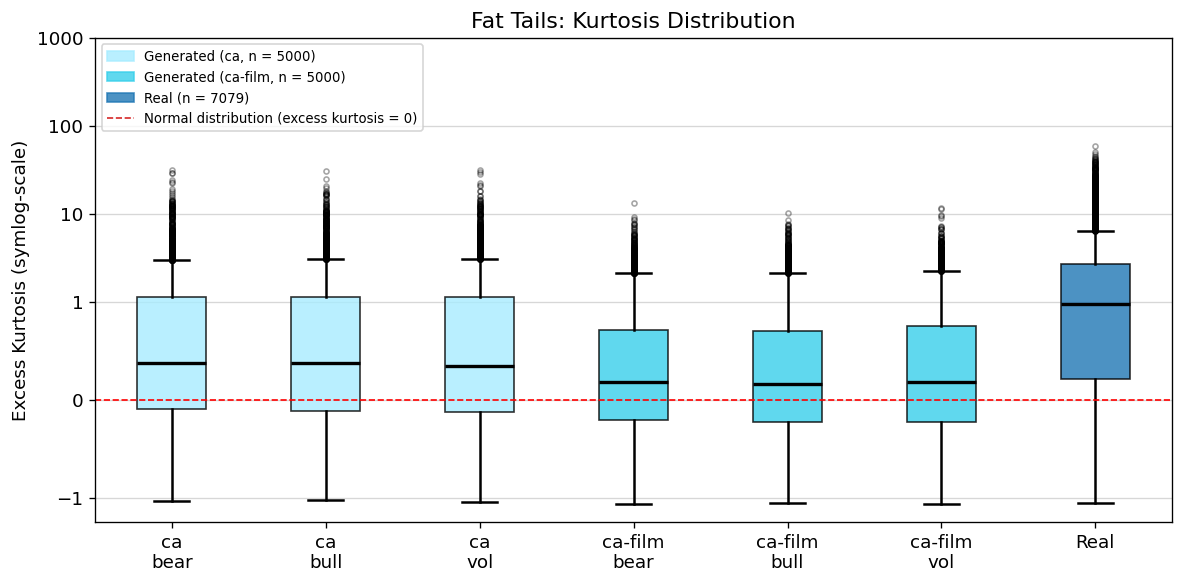

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

# Values
kurt_series = [kurt_gen[(model, cond_key)] for model, cond_key in gen_keys] + [kurt_real]

# Tick labels
tick_labels = [f'{model}\n{cond_key}' for model, cond_key in gen_keys] + [f'Real']

# Boxplot
bp = ax.boxplot(
    kurt_series,
    tick_labels=tick_labels,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.35, linestyle='none'),
)

# Set colors, transparency
for i, (model, _cond_key) in enumerate(gen_keys):
    color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
    bp['boxes'][i].set_facecolor(color)
    bp['boxes'][i].set_alpha(0.8)

bp['boxes'][-1].set_facecolor(C_REAL)
bp['boxes'][-1].set_alpha(0.8)

# Axis settings
ax.set_title('Fat Tails: Kurtosis Distribution')
ax.set_ylabel('Excess Kurtosis (symlog-scale)')
ax.set_yscale('symlog', linthresh=1)
ax.set_ylim(ax.get_ylim()[0], 1000)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)
ax.axhline(0, color='red', linestyle='--', linewidth=1.0, label='Normal distribution (excess kurtosis = 0)')

# Legend
gen_ca_handle = mpatches.Patch(color=C_GEN_CA, alpha=0.8, label=f'Generated (ca, n = {len(gen_data["ca"]["bear"]["samples"])})')
gen_cafilm_handle = mpatches.Patch(color=C_GEN_CAFILM, alpha=0.8, label=f'Generated (ca-film, n = {len(gen_data["ca-film"]["bear"]["samples"])})')
real_handle = mpatches.Patch(color=C_REAL, alpha=0.8, label=f'Real (n = {real_np.shape[0]})')
baseline_handle = Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Normal distribution (excess kurtosis = 0)')
ax.legend(handles=[gen_ca_handle, gen_cafilm_handle, real_handle, baseline_handle], loc='upper left', fontsize=8)

# Plot and save
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('../../figures/kurtosis_boxplot.png')
plt.show()

In [9]:
"""
1.2 - 5% and 95% percentiles.
"""

# Row data
rows = []
for model, cond_key in gen_keys:
    label = f"Gen {model} {cond_key}"
    rows.append((label, np.percentile(flat_gen[(model, cond_key)], [5, 95])))

rows.extend([
    ('Real', np.percentile(flat_real, [5, 95])),
    ('Normal (ref)', norm.ppf([0.05, 0.95])),
])

# Chart
print(f"{'Distribution':24s}  {'5th pct':>10s}  {'95th pct':>10s}  {'Range':>10s}")
print("-" * 60)
for label, (p5, p95) in rows:
    print(f"{label:24s}  {p5:>10.4f}  {p95:>10.4f}  {p95 - p5:>10.4f}")

Distribution                 5th pct    95th pct       Range
------------------------------------------------------------
Gen ca bear                  -1.6630      1.6732      3.3362
Gen ca bull                  -1.6587      1.6757      3.3344
Gen ca vol                   -1.6631      1.6763      3.3394
Gen ca-film bear             -1.4756      1.4800      2.9556
Gen ca-film bull             -1.4732      1.4820      2.9552
Gen ca-film vol              -1.4718      1.4780      2.9498
Real                         -1.5726      1.5899      3.1625
Normal (ref)                 -1.6449      1.6449      3.2897


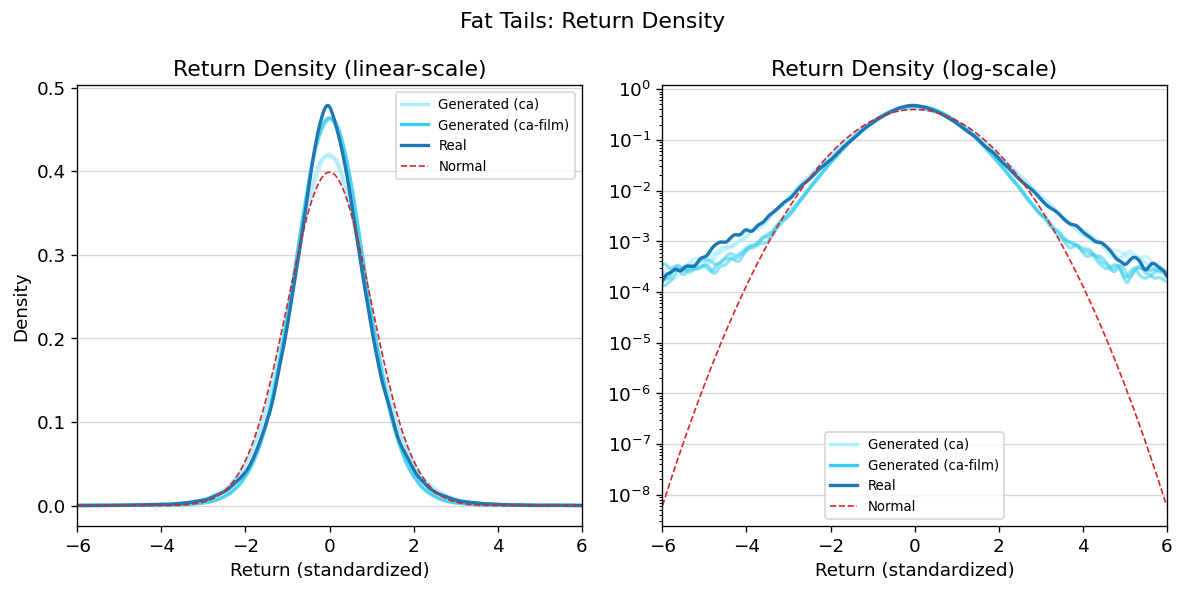

In [13]:
"""
1.3 - KDE overlay.
"""

x_grid = np.linspace(-6, 6, 500)

# KDE curves
kde_gen = {
    (model, cond_key): gaussian_kde(flat_gen[(model, cond_key)], bw_method='scott')(x_grid)
    for model, cond_key in gen_keys
}
kde_real = gaussian_kde(flat_real, bw_method='scott')(x_grid)
pdf_norm = norm.pdf(x_grid)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False)
for ax, yscale in zip(axes, ['linear', 'log']):
    # Generated
    for model, cond_key in gen_keys:
        color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
        ax.plot(x_grid, kde_gen[(model, cond_key)], color=color, lw=2, alpha=0.55)
    # Real
    ax.plot(x_grid, kde_real, color=C_REAL, lw=2)
    # Normal
    ax.plot(x_grid, pdf_norm, color=C_NORMAL, linestyle='--', linewidth=1.0)

    # Legend
    generated_ca_handle = Line2D([0], [0], color=C_GEN_CA, lw=2, label='Generated (ca)')
    generated_cafilm_handle = Line2D([0], [0], color=C_GEN_CAFILM, lw=2, label='Generated (ca-film)')
    real_handle = Line2D([0], [0], color=C_REAL, lw=2, label='Real')
    normal_handle = Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Normal')

    # Axis settings
    ax.set_xlim(-6, 6)
    ax.set_xlabel('Return (standardized)')
    ax.set_yscale(yscale)
    ax.set_title(f'Return Density ({yscale}-scale)')
    ax.legend(handles=[generated_ca_handle, generated_cafilm_handle, real_handle, normal_handle], fontsize=8)
    ax.grid(axis='y', alpha=0.5)

# Axis settings
axes[0].set_ylabel('Density')
fig.suptitle('Fat Tails: Return Density')

# Plot and save
plt.tight_layout()
plt.savefig('../../figures/kde_overlay.png')
plt.show()


In [11]:
"""
2.1 - ACF table.
"""

# Tau lags
TABLE_LAGS = [1, 5, 10, 20, 30]

# ACF values
acf_gen_tbl = {
    (model, cond_key): acf_squared(gen_data[model][cond_key]['samples'], TABLE_LAGS)
    for model, cond_key in gen_keys
}
acf_real_tbl = acf_squared(real_np, TABLE_LAGS)

# Chart
header = f"{'':24s}" + "".join(f"  lag={l:>2d}" for l in TABLE_LAGS)
print(header)
print("-" * len(header))
for model, cond_key in gen_keys:
    label = f"Gen {model} {cond_key}"
    vals = acf_gen_tbl[(model, cond_key)]
    row = f"{label:24s}" + "".join(f"  {v:>7.4f}" for v in vals)
    print(row)

row = f"{'Real':24s}" + "".join(f"  {v:>7.4f}" for v in acf_real_tbl)
print(row)


                          lag= 1  lag= 5  lag=10  lag=20  lag=30
----------------------------------------------------------------
Gen ca bear                0.0536   0.0042  -0.0132  -0.0180  -0.0137
Gen ca bull                0.0544   0.0021  -0.0120  -0.0181  -0.0134
Gen ca vol                 0.0555   0.0043  -0.0116  -0.0183  -0.0129
Gen ca-film bear           0.0352  -0.0036  -0.0128  -0.0121  -0.0112
Gen ca-film bull           0.0346  -0.0058  -0.0120  -0.0129  -0.0107
Gen ca-film vol            0.0356  -0.0053  -0.0112  -0.0106  -0.0098
Real                       0.0303   0.0028  -0.0048  -0.0161  -0.0123


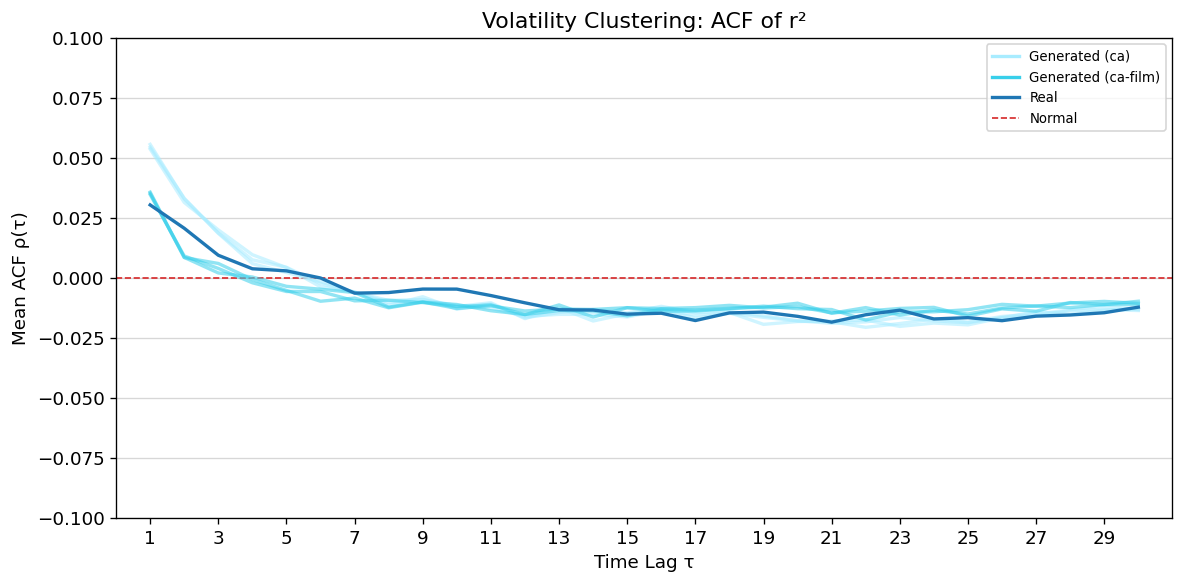

In [14]:
"""
2.2 - ACF plot.
"""
# Tau lags
ALL_LAGS = np.arange(1, 31)

# ACF values
acf_gen_full = {
    (model, cond_key): acf_squared(gen_data[model][cond_key]['samples'], ALL_LAGS)
    for model, cond_key in gen_keys
}
acf_real_full = acf_squared(real_np, ALL_LAGS)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, color=C_NORMAL, linestyle='--', linewidth=1.0)
for model, cond_key in gen_keys:
    color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
    ax.plot(ALL_LAGS, acf_gen_full[(model, cond_key)], color=color, lw=2, alpha=0.55)
ax.plot(ALL_LAGS, acf_real_full, color=C_REAL, lw=2)

# Legend
generated_ca_handle = Line2D([0], [0], color=C_GEN_CA, lw=2, label='Generated (ca)')
generated_cafilm_handle = Line2D([0], [0], color=C_GEN_CAFILM, lw=2, label='Generated (ca-film)')
real_handle = Line2D([0], [0], color=C_REAL, lw=2, label='Real')
normal_handle = Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Normal')

# Axis settings
ax.set_xlabel('Time Lag τ')
ax.set_ylabel('Mean ACF ρ(τ)')
ax.set_title('Volatility Clustering: ACF of r²')
ax.set_xlim(0, 31)
ax.set_xticks(np.arange(1, 31, 2))
ax.set_ylim(-0.1, 0.1)
ax.legend(handles=[generated_ca_handle, generated_cafilm_handle, real_handle, normal_handle], fontsize=8)
ax.grid(axis='y', alpha=0.5)

# Plot and save
plt.tight_layout()
plt.savefig('../../figures/acf_curve.png')
plt.show()
